# Étape 4 — Fine-Tuning de CamemBERT pour la Classification de Sentiments
**Modèle** : `camembert-base` (110M paramètres)
**Tâche** : Classification 3 classes (négatif, neutre, positif)
**Optimisations Colab** : fp16, gradient accumulation, sauvegarde sur Drive

In [1]:
# ═══════════════════════════════════════════════════════
# SETUP + VÉRIFICATION GPU
# ═══════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/Projet_Sentiment_Analysis'
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
FIG_DIR     = os.path.join(PROJECT_DIR, 'figures')
MODEL_DIR   = os.path.join(PROJECT_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

!pip install -q transformers accelerate

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import CamembertTokenizer, CamembertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings('ignore')

# ═══ Reproductibilité ═══
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device : {DEVICE}")

if DEVICE.type == 'cuda':
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print(" PAS DE GPU DÉTECTÉ ! Va dans Exécution → Modifier le type d'exécution → GPU")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Device : cuda
   GPU    : Tesla T4
   VRAM   : 15.6 GB


In [2]:
# ═══════════════════════════════════════════════════════
# CHARGEMENT DES DONNÉES
# ═══════════════════════════════════════════════════════
df_train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val.csv'))
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

# Remplir les NaN
for df_ in [df_train, df_val, df_test]:
    df_['texte_clean'] = df_['texte_clean'].fillna('')

# Définir les noms des labels pour l'affichage
# Assumons que les labels sont encodés comme 0, 1, 2 pour négatif, neutre, positif
LABEL_NAMES = {0: 'négatif', 1: 'neutre', 2: 'positif'}

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print(f"\n Distribution train :")
for label, name in LABEL_NAMES.items():
    n = (df_train['label'] == label).sum()
    print(f"   {name:10s} : {n:>5,} ({100*n/len(df_train):.1f}%)")

📊 Train: 9285 | Val: 1161 | Test: 1161

📊 Distribution train :
   négatif    : 3,158 (34.0%)
   neutre     :   669 (7.2%)
   positif    : 5,458 (58.8%)


In [3]:
# ═══════════════════════════════════════════════════════
# DATASET PYTORCH
# ═══════════════════════════════════════════════════════
class AvisDataset(Dataset):
    """Dataset pour les avis d'applications."""

    def __init__(self, textes, labels, tokenizer, max_length=128):
        self.textes    = textes
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.textes)

    def __getitem__(self, idx):
        texte = str(self.textes[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            texte,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(label, dtype=torch.long)
        }

# Définir le nom du modèle et la longueur maximale
MODEL_NAME = 'camembert-base'
MAX_LEN = 128

# Charger le tokenizer
tokenizer = CamembertTokenizer.from_pretrained(MODEL_NAME)

# Créer les datasets
train_dataset = AvisDataset(df_train['texte_clean'].values, df_train['label'].values, tokenizer, MAX_LEN)
val_dataset   = AvisDataset(df_val['texte_clean'].values, df_val['label'].values, tokenizer, MAX_LEN)
test_dataset  = AvisDataset(df_test['texte_clean'].values, df_test['label'].values, tokenizer, MAX_LEN)

print(f" Datasets créés : Train={len(train_dataset)} | Val={len(val_dataset)} | Test={len(test_dataset)}")

✅ Datasets créés : Train=9285 | Val=1161 | Test=1161


In [4]:
# ═══════════════════════════════════════════════════════
# DATALOADERS AVEC GESTION DU DÉSÉQUILIBRE
# ═══════════════════════════════════════════════════════

# Définir la taille du batch
BATCH_SIZE = 16

# Calculer les poids pour le sampler
class_counts = np.bincount(df_train['label'].values)
class_weights_array = 1.0 / class_counts
sample_weights = class_weights_array[df_train['label'].values]
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Class weights pour la loss (en complément du sampler)
cw = compute_class_weight('balanced', classes=np.array([0,1,2]), y=df_train['label'].values)
class_weights = torch.FloatTensor(cw).to(DEVICE)
print(f" Class weights : {cw.round(4)}")

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f" DataLoaders créés")
print(f"   Batches par epoch : {len(train_loader)}")

⚖️ Class weights : [0.9801 4.6263 0.5671]
✅ DataLoaders créés
   Batches par epoch : 581


In [5]:
# ═══════════════════════════════════════════════════════
# CHARGER CAMEMBERT POUR LA CLASSIFICATION
# ═══════════════════════════════════════════════════════
# Définir le nombre de classes pour la classification
NUM_CLASSES = 3

model = CamembertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
)
model.to(DEVICE)

# Compter les paramètres
total_params = sum(p.numel() for p in model.parameters())
trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f" Paramètres totaux     : {total_params:>12,}")
print(f" Paramètres entraînables : {trainable:>12,}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


📐 Paramètres totaux     :  110,624,259
📐 Paramètres entraînables :  110,624,259


In [9]:
# ═══════════════════════════════════════════════════════
# OPTIMIZER + SCHEDULER + FP16
# ═══════════════════════════════════════════════════════

# Hyperparamètres
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
EPOCHS = 3
GRAD_ACCUM = 1 # Pas d'accumulation de gradient pour l'instant
WARMUP_RATIO = 0.06 # 6% des étapes totales pour le warmup
FP16 = True # Activer la précision mixte

# Optimizer : AdamW avec weight decay
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Scheduler : linear warmup + decay
total_steps = len(train_loader) * EPOCHS // GRAD_ACCUM
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Mixed precision (FP16) pour économiser la VRAM
scaler = torch.amp.GradScaler('cuda', enabled=FP16)

# Loss avec class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(f" Optimizer : AdamW (lr={LEARNING_RATE})")
print(f" Scheduler : Linear warmup ({warmup_steps} steps) + decay ({total_steps} total)")
print(f" FP16 : {'Activé' if FP16 else 'Désactivé'}")

✅ Optimizer : AdamW (lr=2e-05)
✅ Scheduler : Linear warmup (104 steps) + decay (1743 total)
✅ FP16 : Activé


In [10]:
# ═══════════════════════════════════════════════════════
# FONCTIONS TRAIN / EVAL
# ═══════════════════════════════════════════════════════

def train_epoch(model, loader, criterion, optimizer, scheduler, scaler, device, grad_accum):
    """Entraîne le modèle pour une epoch."""
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    optimizer.zero_grad()

    pbar = tqdm(loader, desc="Training")
    for step, batch in enumerate(pbar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        with torch.amp.autocast('cuda', enabled=FP16):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels) / grad_accum

        scaler.scale(loss).backward()

        if (step + 1) % grad_accum == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * grad_accum
        preds = outputs.logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({'loss': f'{loss.item()*grad_accum:.4f}'})

    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, f1


def eval_epoch(model, loader, criterion, device):
    """Évalue le modèle sur un dataset."""
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            with torch.amp.autocast('cuda', enabled=FP16):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs.logits, labels)

            total_loss += loss.item()
            preds = outputs.logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, f1, acc, np.array(all_preds), np.array(all_labels)

print("✅ Fonctions définies")

✅ Fonctions définies


In [11]:
# ═══════════════════════════════════════════════════════
# 🚀 ENTRAÎNEMENT — BOUCLE PRINCIPALE
# ═══════════════════════════════════════════════════════
history = {
    'train_loss': [], 'train_f1': [],
    'val_loss': [], 'val_f1': [], 'val_acc': []
}

best_val_f1 = 0
best_epoch  = 0
save_path   = os.path.join(MODEL_DIR, 'best_camembert')

print("="*60)
print(" DÉBUT DU FINE-TUNING")
print("="*60)

for epoch in range(EPOCHS):
    print(f"\n{'─'*60}")
    print(f" EPOCH {epoch+1}/{EPOCHS}")
    print(f"{'─'*60}")

    # --- Entraînement ---
    train_loss, train_f1 = train_epoch(
        model, train_loader, criterion, optimizer, scheduler, scaler, DEVICE, GRAD_ACCUM
    )

    # --- Validation ---
    val_loss, val_f1, val_acc, _, _ = eval_epoch(
        model, val_loader, criterion, DEVICE
    )

    # Sauvegarder l'historique
    history['train_loss'].append(train_loss)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_acc'].append(val_acc)

    print(f"\n Epoch {epoch+1} Résumé :")
    print(f"   Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f}")
    print(f"   Val Loss:   {val_loss:.4f} | Val F1:   {val_f1:.4f} | Val Acc: {val_acc:.4f}")

    # Sauvegarder le meilleur modèle
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        model.save_pretrained(save_path)
        tokenizer.save_pretrained(save_path)
        print(f"     Nouveau meilleur modèle sauvegardé ! (F1={val_f1:.4f})")
    else:
        print(f"   ℹ Pas d'amélioration (best: {best_val_f1:.4f} à epoch {best_epoch})")

print(f"\n{'='*60}")
print(f" ENTRAÎNEMENT TERMINÉ")
print(f"   Meilleur F1-macro : {best_val_f1:.4f} (epoch {best_epoch})")
print(f"   Modèle sauvegardé : {save_path}")
print(f"{'='*60}")

🚀 DÉBUT DU FINE-TUNING

────────────────────────────────────────────────────────────
📌 EPOCH 1/3
────────────────────────────────────────────────────────────


Evaluating: 100%|██████████| 73/73 [00:02<00:00, 31.14it/s]



📊 Epoch 1 Résumé :
   Train Loss: 0.6383 | Train F1: 0.4751
   Val Loss:   0.9360 | Val F1:   0.5433 | Val Acc: 0.5814


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 ★ Nouveau meilleur modèle sauvegardé ! (F1=0.5433)

────────────────────────────────────────────────────────────
📌 EPOCH 2/3
────────────────────────────────────────────────────────────


...

   💾 ★ Nouveau meilleur modèle sauvegardé ! (F1=0.5786)

────────────────────────────────────────────────────────────
📌 EPOCH 3/3
────────────────────────────────────────────────────────────


Evaluating: 100%|██████████| 73/73 [00:02<00:00, 28.93it/s]


📊 Epoch 3 Résumé :
   Train Loss: 0.2812 | Train F1: 0.8452
   Val Loss:   1.1436 | Val F1:   0.6105 | Val Acc: 0.7450


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 ★ Nouveau meilleur modèle sauvegardé ! (F1=0.6105)

✅ ENTRAÎNEMENT TERMINÉ
   Meilleur F1-macro : 0.6105 (epoch 3)
   Modèle sauvegardé : /content/drive/MyDrive/Projet_Sentiment_Analysis/models/best_camembert


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 73/73 [00:06<00:00, 11.40it/s]


📊 RÉSULTATS FINAUX — CamemBERT Fine-Tuné
   Accuracy  : 0.7476
   F1-macro  : 0.6316

📋 Classification Report :
              precision    recall  f1-score   support

     négatif       0.82      0.83      0.82       395
      neutre       0.17      0.45      0.25        84
     positif       0.94      0.74      0.83       682

    accuracy                           0.75      1161
   macro avg       0.64      0.67      0.63      1161
weighted avg       0.84      0.75      0.78      1161



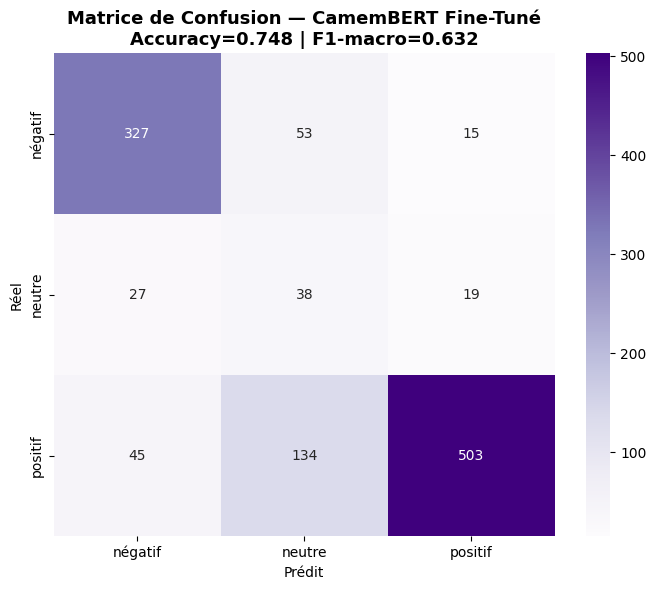

In [12]:
# ═══════════════════════════════════════════════════════
# ÉVALUATION FINALE SUR LE TEST SET
# ═══════════════════════════════════════════════════════

# Recharger le meilleur modèle
model_best = CamembertForSequenceClassification.from_pretrained(save_path)
model_best.to(DEVICE)

test_loss, test_f1, test_acc, test_preds, test_labels = eval_epoch(
    model_best, test_loader, criterion, DEVICE
)

print("="*60)
print("📊 RÉSULTATS FINAUX — CamemBERT Fine-Tuné")
print("="*60)
print(f"   Accuracy  : {test_acc:.4f}")
print(f"   F1-macro  : {test_f1:.4f}")
print(f"\n Classification Report :")
print(classification_report(test_labels, test_preds, target_names=['négatif','neutre','positif']))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['négatif','neutre','positif'],
            yticklabels=['négatif','neutre','positif'])
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title(f'Matrice de Confusion — CamemBERT Fine-Tuné\nAccuracy={test_acc:.3f} | F1-macro={test_f1:.3f}',
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_camembert_finetuned.png'), dpi=150, bbox_inches='tight')
plt.show()

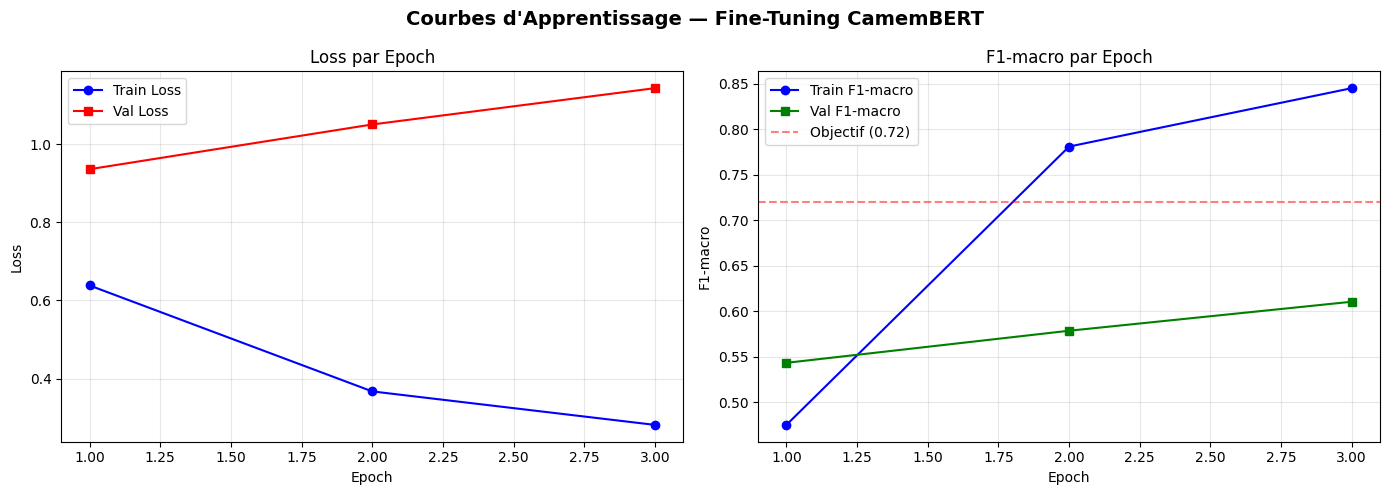

In [13]:
# ═══════════════════════════════════════════════════════
# COURBES D'APPRENTISSAGE DU FINE-TUNING
# ═══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss'])+1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'], 'r-s', label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss par Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1-macro
axes[1].plot(epochs_range, history['train_f1'], 'b-o', label='Train F1-macro')
axes[1].plot(epochs_range, history['val_f1'], 'g-s', label='Val F1-macro')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1-macro')
axes[1].set_title('F1-macro par Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0.72, color='red', linestyle='--', alpha=0.5, label='Objectif (0.72)')
axes[1].legend()

plt.suptitle('Courbes d\'Apprentissage — Fine-Tuning CamemBERT', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'courbes_finetuning.png'), dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Sauvegarder les prédictions pour le notebook 05
import numpy as np

np.save(os.path.join(DATA_DIR, 'test_preds_camembert.npy'), test_preds)
np.save(os.path.join(DATA_DIR, 'test_labels.npy'), test_labels)

print("✅ Prédictions sauvegardées sur Drive")

✅ Prédictions sauvegardées sur Drive
